In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import minimize_scalar

mu_max = 0.3
K_S = 0.8
K_I = 100.0

Y_XS = 0.45
Y_XP = 0.15

V0 = 0.85
X0 = 30.0
S_initial = 0.0
P0 = 0.0

S0 = 80.0

F_I = 0.2
F_P = 0.5
F_H = 2.5

t_initiation = 1.0
t_processing = 5.0
t_harvesting = 1.0
cycle_time = t_processing + t_harvesting

n_cycles = 10

In [2]:
def mu_net(S):
    S = max(S, 0.0)
    if S == 0:
        return 0.0
    return mu_max * S / (K_S + S + S**2 / K_I)

In [3]:
def fedbatch_rhs(t, y, phase, S_P):
    N_X, N_S, N_P, V, H = y

    V = max(V, 1e-12)

    X = max(N_X / V, 0.0)
    S = max(N_S / V, 0.0)
    P = max(N_P / V, 0.0)

    mu = mu_net(S)

    biomass_growth = mu * X * V
    substrate_consumption = biomass_growth / Y_XS
    product_formation = biomass_growth / Y_XP

    if phase == "initiation":
        dN_Xdt = biomass_growth
        dN_Sdt = F_I * S0 - substrate_consumption
        dN_Pdt = product_formation
        dVdt = F_I
        dHdt = 0.0

    elif phase == "processing":
        dN_Xdt = biomass_growth
        dN_Sdt = F_P * S_P - substrate_consumption
        dN_Pdt = product_formation
        dVdt = F_P
        dHdt = 0.0

    elif phase == "harvesting":
        dN_Xdt = -F_H * X + biomass_growth
        dN_Sdt = -F_H * S - substrate_consumption
        dN_Pdt = -F_H * P + product_formation
        dVdt = -F_H
        dHdt = F_H * P

    else:
        raise ValueError("phase must be 'initiation', 'processing', or 'harvesting'.")

    return [dN_Xdt, dN_Sdt, dN_Pdt, dVdt, dHdt]

In [4]:
def solve_phase(y0, t0, duration, phase, S_P):
    sol = solve_ivp(
        lambda t, y: fedbatch_rhs(t, y, phase, S_P),
        (t0, t0 + duration),
        y0,
        method="BDF",
        rtol=1e-6,
        atol=1e-9
    )

    if not sol.success:
        raise RuntimeError(sol.message)

    return sol

In [5]:
def simulate_fedbatch(S_P, n_cycles=10, return_profile=False):
    y0 = np.array([
        X0 * V0,
        S_initial * V0,
        P0 * V0,
        V0,
        0.0
    ])

    t_current = 0.0
    y_current = y0.copy()

    all_t = []
    all_y = []

    sol = solve_phase(y_current, t_current, t_initiation, "initiation", S_P)
    all_t.append(sol.t)
    all_y.append(sol.y)

    y_current = sol.y[:, -1]
    t_current = sol.t[-1]

    harvested_per_cycle = []

    for cycle in range(1, n_cycles + 1):
        sol = solve_phase(y_current, t_current, t_processing, "processing", S_P)
        all_t.append(sol.t)
        all_y.append(sol.y)

        y_current = sol.y[:, -1]
        t_current = sol.t[-1]

        H_before = y_current[4]

        sol = solve_phase(y_current, t_current, t_harvesting, "harvesting", S_P)
        all_t.append(sol.t)
        all_y.append(sol.y)

        y_current = sol.y[:, -1]
        t_current = sol.t[-1]

        H_after = y_current[4]
        harvested_per_cycle.append(H_after - H_before)

    production_rate = harvested_per_cycle[-1] / cycle_time

    if return_profile:
        T = np.concatenate(all_t)
        Y = np.hstack(all_y)

        N_X = Y[0]
        N_S = Y[1]
        N_P = Y[2]
        V = Y[3]

        X = N_X / V
        S = N_S / V
        P = N_P / V

        return T, X, S, P, V, harvested_per_cycle, production_rate

    return production_rate

In [6]:
S_P_values = np.linspace(10, 160, 151)

production_rates = []

for S_P in S_P_values:
    rate = simulate_fedbatch(S_P, n_cycles=n_cycles)
    production_rates.append(rate)

production_rates = np.array(production_rates)

In [7]:
best_index = np.argmax(production_rates)
best_S_P_grid = S_P_values[best_index]
best_rate_grid = production_rates[best_index]

print(f"Best S_P from grid search = {best_S_P_grid:.2f} g/L")
print(f"Maximum production rate from grid search = {best_rate_grid:.4f} g/h")

Best S_P from grid search = 110.00 g/L
Maximum production rate from grid search = 137.4624 g/h


In [8]:
def objective(S_P):
    return -simulate_fedbatch(S_P, n_cycles=n_cycles)

res = minimize_scalar(
    objective,
    bounds=(10, 160),
    method="bounded",
    options={"xatol": 1e-3}
)

best_S_P = res.x
best_rate = -res.fun

print(f"Optimal S_P = {best_S_P:.4f} g/L")
print(f"Maximum production rate = {best_rate:.4f} g/h")

Optimal S_P = 110.1143 g/L
Maximum production rate = 137.6001 g/h


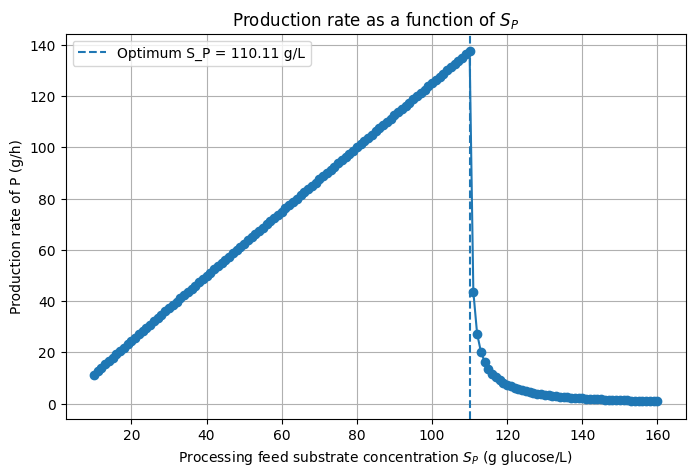

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(S_P_values, production_rates, marker="o")
plt.axvline(best_S_P, linestyle="--", label=f"Optimum S_P = {best_S_P:.2f} g/L")
plt.xlabel("Processing feed substrate concentration $S_P$ (g glucose/L)")
plt.ylabel("Production rate of P (g/h)")
plt.title("Production rate as a function of $S_P$")
plt.legend()
plt.grid(True)
plt.show()

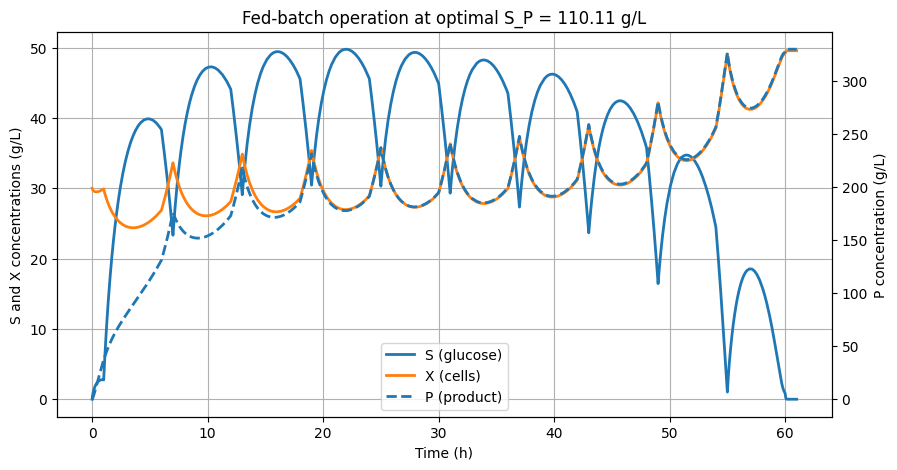

Product harvested during cycle 10 = 825.6007 g
Production rate during cycle 10 = 137.6001 g/h


In [10]:
T, X, S, P, V, harvested_per_cycle, production_rate = simulate_fedbatch(
    best_S_P,
    n_cycles=n_cycles,
    return_profile=True
)

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(T, S, label="S (glucose)", linewidth=2)
ax1.plot(T, X, label="X (cells)", linewidth=2)
ax1.set_xlabel("Time (h)")
ax1.set_ylabel("S and X concentrations (g/L)")
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(T, P, label="P (product)", linestyle="--", linewidth=2)
ax2.set_ylabel("P concentration (g/L)")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="best")

plt.title(f"Fed-batch operation at optimal S_P = {best_S_P:.2f} g/L")
plt.show()

print(f"Product harvested during cycle 10 = {harvested_per_cycle[-1]:.4f} g")
print(f"Production rate during cycle 10 = {production_rate:.4f} g/h")

In [11]:
recommended_S_P = 100.0

rate_recommended = simulate_fedbatch(recommended_S_P, n_cycles=n_cycles)

print(f"Recommended robust S_P = {recommended_S_P:.2f} g/L")
print(f"Production rate at recommended S_P = {rate_recommended:.4f} g/h")
print(f"Loss compared to mathematical optimum = {best_rate - rate_recommended:.4f} g/h")

Recommended robust S_P = 100.00 g/L
Production rate at recommended S_P = 124.9597 g/h
Loss compared to mathematical optimum = 12.6404 g/h
